In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [65]:
df=pd.read_csv("/home/asad-shareef/Personel/Nothing/final_THP.csv")
df=df.sort_values(by=["district","crop"])
df=df[df["crop"]=="rice"]
df["flag"]=df["kg/acre"]==0
df

,district,year,crop,germ_temp,veg_temp,flow_temp,fruit_temp,germ_rh,veg_rh,flow_rh,fruit_rh,germ_prec,veg_prec,flow_prec,fruit_prec,n__g/kg,soc__g/kg,soil_ph,kg/acre,flag
2,attock,1981,rice,36.22,33.65,30.48,28.88,17.88,50.79,65.07,52.33,21.77,144.05,135.21,12.79,1.538567,16.76787,7.54444,0.000000,True
5,attock,1982,rice,32.66,35.98,32.43,30.65,36.26,31.02,52.64,23.44,15.01,33.53,87.22,6.98,1.538567,16.76787,7.54444,0.000000,True
8,attock,1983,rice,32.44,34.20,30.97,28.70,34.13,39.48,63.55,56.73,32.39,61.77,215.80,42.72,1.538567,16.76787,7.54444,0.000000,True
11,attock,1984,rice,37.32,32.39,30.96,26.86,22.36,53.92,65.28,60.04,34.25,177.95,70.45,111.30,1.538567,16.76787,7.54444,0.000000,True
14,attock,1985,rice,36.56,33.43,31.07,30.28,16.81,48.98,61.65,36.61,2.24,107.52,122.26,5.82,1.538567,16.76787,7.54444,0.000000,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3683,vehari,2020,rice,37.26,36.85,35.29,31.30,35.73,43.61,50.20,54.18,38.87,72.46,52.35,83.50,1.546484,9.56018,7.59187,900.404858,False
3686,vehari,2021,rice,36.42,37.61,36.62,32.94,35.88,38.50,35.94,51.60,35.62,32.28,12.29,37.25,1.546484,9.56018,7.59187,1007.692308,False
3689,vehari,2022,rice,36.61,32.15,30.21,31.09,30.52,70.45,75.96,61.08,38.15,301.18,92.22,10.76,1.546484,9.56018,7.59187,1041.295547,False
3692,vehari,2023,rice,34.05,34.19,35.22,33.94,52.08,58.70,46.45,40.91,45.76,120.99,8.50,25.37,1.546484,9.56018,7.59187,1123.886640,False


In [66]:
low=df["kg/acre"].quantile(0.01)
high=df["kg/acre"].quantile(0.99)
df=df[(df["kg/acre"]>=low)&(df["kg/acre"]<=high)]

In [67]:
df["soil"]=df["n__g/kg"]+df["soc__g/kg"]
df["total_prec"]=df["germ_prec"]+df["veg_prec"]+df["flow_prec"]+df["fruit_prec"]
df["avg_rh"]=(df["germ_rh"]+df["veg_rh"]+df["flow_rh"]+df["fruit_rh"])/4
df["avg_temp"]=(df["germ_temp"]+df["veg_temp"]+df["flow_temp"]+df["fruit_temp"])/4

In [68]:
df.columns

Index(['district', 'year', 'crop', 'germ_temp', 'veg_temp', 'flow_temp',
       'fruit_temp', 'germ_rh', 'veg_rh', 'flow_rh', 'fruit_rh', 'germ_prec',
       'veg_prec', 'flow_prec', 'fruit_prec', 'n__g/kg', 'soc__g/kg',
       'soil_ph', 'kg/acre', 'flag', 'soil', 'total_prec', 'avg_rh',
       'avg_temp'],
      dtype='str')

In [69]:
dfc=df.drop(["district","crop"],axis=1)

In [70]:
dfc.corr()

,year,germ_temp,veg_temp,flow_temp,fruit_temp,germ_rh,veg_rh,flow_rh,fruit_rh,germ_prec,...,fruit_prec,n__g/kg,soc__g/kg,soil_ph,kg/acre,flag,soil,total_prec,avg_rh,avg_temp
year,1.000000,-0.277825,-0.194180,-0.107916,-0.112390,0.518051,0.362824,0.199162,0.413903,0.336051,...,0.234798,0.004218,0.004871,-0.005671,0.547925,-0.243510,0.004866,0.281598,0.426646,-0.186432
germ_temp,-0.277825,1.000000,0.633180,0.585722,0.513496,-0.686067,-0.482894,-0.493335,-0.377843,-0.631402,...,-0.200727,-0.463281,-0.608803,0.283786,0.161511,-0.297816,-0.602805,-0.580823,-0.585109,0.747325
veg_temp,-0.194180,0.633180,1.000000,0.838247,0.733537,-0.373021,-0.916496,-0.777162,-0.662324,-0.500009,...,-0.443406,-0.447286,-0.633435,0.296423,0.144793,-0.261018,-0.624260,-0.822877,-0.848072,0.918997
flow_temp,-0.107916,0.585722,0.838247,1.000000,0.828767,-0.257196,-0.740348,-0.950284,-0.736112,-0.403879,...,-0.421627,-0.466517,-0.673084,0.325137,0.209812,-0.297982,-0.662594,-0.861146,-0.860748,0.941187
fruit_temp,-0.112390,0.513496,0.733537,0.828767,1.000000,-0.166880,-0.580618,-0.772301,-0.834096,-0.352346,...,-0.671798,-0.460845,-0.662864,0.318510,0.215340,-0.293367,-0.652652,-0.798707,-0.769227,0.890113
germ_rh,0.518051,-0.686067,-0.373021,-0.257196,-0.166880,1.000000,0.433537,0.294054,0.255150,0.733561,...,0.073958,0.120042,0.149997,-0.090239,0.215259,-0.052897,0.149018,0.398874,0.520626,-0.393576
veg_rh,0.362824,-0.482894,-0.916496,-0.740348,-0.580618,0.433537,1.000000,0.777576,0.678611,0.503806,...,0.402417,0.287272,0.429826,-0.209790,0.064923,0.084807,0.422228,0.808945,0.890341,-0.784550
flow_rh,0.199162,-0.493335,-0.777162,-0.950284,-0.772301,0.294054,0.777576,1.000000,0.803275,0.419990,...,0.428319,0.352867,0.537872,-0.266347,-0.068310,0.178326,0.527805,0.888060,0.920298,-0.870134
fruit_rh,0.413903,-0.377843,-0.662324,-0.736112,-0.834096,0.255150,0.678611,0.803275,1.000000,0.384144,...,0.743589,0.303598,0.465712,-0.234323,0.079550,0.074714,0.456832,0.844858,0.885410,-0.760364
germ_prec,0.336051,-0.631402,-0.500009,-0.403879,-0.352346,0.733561,0.503806,0.419990,0.384144,1.000000,...,0.217506,0.195996,0.298027,-0.149393,0.047943,0.048010,0.292489,0.611896,0.577332,-0.520402


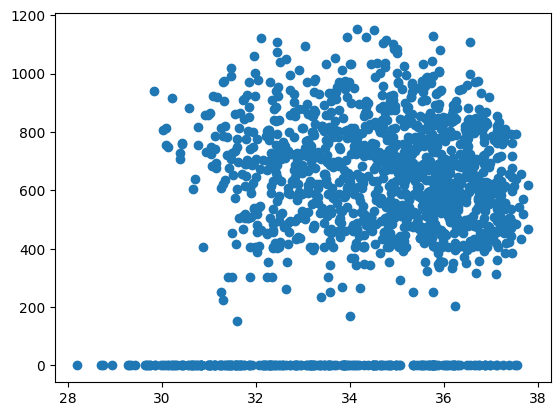

In [71]:
plt.scatter(df["avg_temp"],df["kg/acre"])

In [72]:
df=df.drop([  'n__g/kg', 'soc__g/kg','avg_rh','avg_temp'],axis=1)

<Axes: xlabel='total_prec', ylabel='kg/acre'>

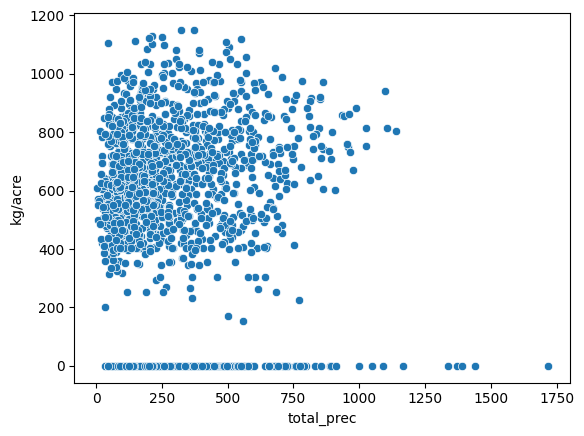

In [73]:
sns.scatterplot(x="total_prec",y="kg/acre",data=df)

In [74]:
df[df["total_prec"]>1000]

,district,year,crop,germ_temp,veg_temp,flow_temp,fruit_temp,germ_rh,veg_rh,flow_rh,fruit_rh,germ_prec,veg_prec,flow_prec,fruit_prec,soil_ph,kg/acre,flag,soil,total_prec
119,attock,2020,rice,29.35,30.63,29.48,27.66,64.69,66.58,78.39,67.25,641.79,208.51,388.02,134.01,7.54444,0.000000,True,18.306437,1372.33
125,attock,2022,rice,32.89,29.69,28.85,27.17,36.04,75.95,76.09,77.43,120.13,421.61,271.97,187.27,7.54444,0.000000,True,18.306437,1000.98
131,attock,2024,rice,33.92,33.28,29.03,28.26,36.89,60.17,81.19,72.87,56.81,716.33,494.31,71.27,7.54444,0.000000,True,18.306437,1338.72
515,chakwal,2020,rice,28.77,30.09,29.19,26.97,66.61,70.11,79.70,72.29,751.41,235.59,380.99,72.49,7.57034,0.000000,True,18.048532,1440.48
521,chakwal,2022,rice,32.91,29.04,28.45,26.85,36.09,78.67,79.42,78.30,143.68,570.64,191.82,185.93,7.57034,0.000000,True,18.048532,1092.07
527,chakwal,2024,rice,35.89,33.16,28.73,27.78,26.16,60.94,82.89,76.45,25.97,444.27,493.20,84.75,7.57034,0.000000,True,18.048532,1048.19
1577,gujrat,2022,rice,35.07,30.82,29.35,27.83,33.25,73.70,80.99,78.38,110.53,483.44,248.72,181.49,7.46036,753.846154,False,14.566046,1024.18
383,jhelum,2020,rice,30.03,31.34,29.87,28.11,60.96,64.97,77.73,69.20,387.37,218.94,434.27,56.43,7.28356,940.485830,False,17.678553,1097.01
389,jhelum,2022,rice,33.60,29.75,29.13,27.61,36.24,76.59,78.16,76.24,142.88,581.84,222.74,193.92,7.28356,805.668016,False,17.678553,1141.38
1976,narowal,2023,rice,32.88,29.83,29.72,27.97,52.45,79.53,80.32,77.25,209.09,482.89,245.59,168.79,7.57053,814.979757,False,17.377031,1106.36


In [75]:
df["water_stress"]=df["total_prec"]>1000

In [76]:
df

,district,year,crop,germ_temp,veg_temp,flow_temp,fruit_temp,germ_rh,veg_rh,flow_rh,...,germ_prec,veg_prec,flow_prec,fruit_prec,soil_ph,kg/acre,flag,soil,total_prec,water_stress
2,attock,1981,rice,36.22,33.65,30.48,28.88,17.88,50.79,65.07,...,21.77,144.05,135.21,12.79,7.54444,0.000000,True,18.306437,313.82,False
5,attock,1982,rice,32.66,35.98,32.43,30.65,36.26,31.02,52.64,...,15.01,33.53,87.22,6.98,7.54444,0.000000,True,18.306437,142.74,False
8,attock,1983,rice,32.44,34.20,30.97,28.70,34.13,39.48,63.55,...,32.39,61.77,215.80,42.72,7.54444,0.000000,True,18.306437,352.68,False
11,attock,1984,rice,37.32,32.39,30.96,26.86,22.36,53.92,65.28,...,34.25,177.95,70.45,111.30,7.54444,0.000000,True,18.306437,393.95,False
14,attock,1985,rice,36.56,33.43,31.07,30.28,16.81,48.98,61.65,...,2.24,107.52,122.26,5.82,7.54444,0.000000,True,18.306437,237.84,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3683,vehari,2020,rice,37.26,36.85,35.29,31.30,35.73,43.61,50.20,...,38.87,72.46,52.35,83.50,7.59187,900.404858,False,11.106664,247.18,False
3686,vehari,2021,rice,36.42,37.61,36.62,32.94,35.88,38.50,35.94,...,35.62,32.28,12.29,37.25,7.59187,1007.692308,False,11.106664,117.44,False
3689,vehari,2022,rice,36.61,32.15,30.21,31.09,30.52,70.45,75.96,...,38.15,301.18,92.22,10.76,7.59187,1041.295547,False,11.106664,442.31,False
3692,vehari,2023,rice,34.05,34.19,35.22,33.94,52.08,58.70,46.45,...,45.76,120.99,8.50,25.37,7.59187,1123.886640,False,11.106664,200.62,False


In [77]:
df.info()

<class 'pandas.DataFrame'>
Index: 1524 entries, 2 to 3695
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   district      1524 non-null   str    
 1   year          1524 non-null   int64  
 2   crop          1524 non-null   str    
 3   germ_temp     1524 non-null   float64
 4   veg_temp      1524 non-null   float64
 5   flow_temp     1524 non-null   float64
 6   fruit_temp    1524 non-null   float64
 7   germ_rh       1524 non-null   float64
 8   veg_rh        1524 non-null   float64
 9   flow_rh       1524 non-null   float64
 10  fruit_rh      1524 non-null   float64
 11  germ_prec     1524 non-null   float64
 12  veg_prec      1524 non-null   float64
 13  flow_prec     1524 non-null   float64
 14  fruit_prec    1524 non-null   float64
 15  soil_ph       1524 non-null   float64
 16  kg/acre       1524 non-null   float64
 17  flag          1524 non-null   bool   
 18  soil          1524 non-null   float64
 19  t

In [78]:
df.describe()

,year,germ_temp,veg_temp,flow_temp,fruit_temp,germ_rh,veg_rh,flow_rh,fruit_rh,germ_prec,veg_prec,flow_prec,fruit_prec,soil_ph,kg/acre,soil,total_prec
count,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000,1524.000000
mean,2002.355643,37.120446,35.676378,33.750702,31.404692,27.373163,44.725879,51.396621,44.785932,39.976831,115.663537,97.045269,47.046877,7.643823,549.461944,12.266828,299.732513
std,12.656979,1.706466,2.242208,2.461449,2.265004,7.838151,11.231097,13.595934,13.897758,54.060682,103.873356,85.535429,51.156029,0.333359,294.257921,4.309312,225.348229
min,1981.000000,27.800000,28.660000,27.610000,25.070000,13.220000,19.200000,26.560000,17.010000,0.000000,0.010000,0.030000,0.000000,6.358080,0.000000,6.985000,3.390000
25%,1991.000000,36.200000,34.040000,31.760000,29.627500,22.060000,36.550000,40.392500,33.580000,10.737500,37.660000,31.600000,11.475000,7.555000,438.663968,9.138000,124.580000
50%,2002.000000,37.430000,35.970000,34.115000,31.485000,25.330000,43.270000,49.040000,42.055000,26.080000,84.905000,71.170000,31.640000,7.711910,605.263158,11.541315,228.840000
75%,2013.000000,38.410000,37.422500,35.760000,33.290000,31.612500,52.465000,61.840000,55.610000,49.600000,163.570000,139.620000,63.500000,7.878000,753.542510,13.754063,430.520000
max,2024.000000,40.210000,40.580000,38.830000,36.330000,67.650000,79.530000,82.890000,79.150000,990.990000,716.330000,593.570000,405.380000,8.030080,1151.012146,28.791581,1716.900000


In [79]:
df["district"].value_counts()

district
attock             44
bahawalpur         44
bhakkar            44
bhawalnagar        44
chakwal            44
faisalabad         44
gujranwala         44
gujrat             44
hafizabad          44
jhang              44
jhelum             44
khanewal           44
khushab            44
lahore             44
layyah             44
mianwali           44
multan             44
muzaffargarh       44
nankana sahib      44
narowal            44
pakpattan          44
rahim yar khan     44
rawalpindi         44
sargodha           44
sheikhupura        44
vehari             44
kasur              43
lodhran            43
mandi bahauddin    43
sahiwal            43
toba tek singh     43
okara              42
sialkot            42
rajanpur           41
dera ghazi khan    40
Name: count, dtype: int64

In [80]:
df.columns

Index(['district', 'year', 'crop', 'germ_temp', 'veg_temp', 'flow_temp',
       'fruit_temp', 'germ_rh', 'veg_rh', 'flow_rh', 'fruit_rh', 'germ_prec',
       'veg_prec', 'flow_prec', 'fruit_prec', 'soil_ph', 'kg/acre', 'flag',
       'soil', 'total_prec', 'water_stress'],
      dtype='str')

In [81]:
cat_col=["district",'crop']
num_col=[ 'year','germ_temp', 'veg_temp', 'flow_temp', 'fruit_temp',
        'germ_prec', 'veg_prec',
       'flow_prec', 'fruit_prec', 'soil_ph','soil','total_prec','germ_rh', 'veg_rh', 'flow_rh', 'fruit_rh']

In [82]:
df=pd.get_dummies(df,columns=cat_col)

In [83]:
df

,year,germ_temp,veg_temp,flow_temp,fruit_temp,germ_rh,veg_rh,flow_rh,fruit_rh,germ_prec,...,district_rahim yar khan,district_rajanpur,district_rawalpindi,district_sahiwal,district_sargodha,district_sheikhupura,district_sialkot,district_toba tek singh,district_vehari,crop_rice
2,1981,36.22,33.65,30.48,28.88,17.88,50.79,65.07,52.33,21.77,...,False,False,False,False,False,False,False,False,False,True
5,1982,32.66,35.98,32.43,30.65,36.26,31.02,52.64,23.44,15.01,...,False,False,False,False,False,False,False,False,False,True
8,1983,32.44,34.20,30.97,28.70,34.13,39.48,63.55,56.73,32.39,...,False,False,False,False,False,False,False,False,False,True
11,1984,37.32,32.39,30.96,26.86,22.36,53.92,65.28,60.04,34.25,...,False,False,False,False,False,False,False,False,False,True
14,1985,36.56,33.43,31.07,30.28,16.81,48.98,61.65,36.61,2.24,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3683,2020,37.26,36.85,35.29,31.30,35.73,43.61,50.20,54.18,38.87,...,False,False,False,False,False,False,False,False,True,True
3686,2021,36.42,37.61,36.62,32.94,35.88,38.50,35.94,51.60,35.62,...,False,False,False,False,False,False,False,False,True,True
3689,2022,36.61,32.15,30.21,31.09,30.52,70.45,75.96,61.08,38.15,...,False,False,False,False,False,False,False,False,True,True
3692,2023,34.05,34.19,35.22,33.94,52.08,58.70,46.45,40.91,45.76,...,False,False,False,False,False,False,False,False,True,True


In [84]:
x=df.drop("kg/acre",axis=1)
y=df["kg/acre"]

In [85]:
from sklearn.model_selection import train_test_split

In [86]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0,shuffle=True)

In [87]:
x_train

,year,germ_temp,veg_temp,flow_temp,fruit_temp,germ_rh,veg_rh,flow_rh,fruit_rh,germ_prec,...,district_rahim yar khan,district_rajanpur,district_rawalpindi,district_sahiwal,district_sargodha,district_sheikhupura,district_sialkot,district_toba tek singh,district_vehari,crop_rice
3857,1990,37.80,37.43,34.65,33.12,21.40,30.90,43.76,32.81,13.30,...,False,False,False,False,False,False,False,False,False,True
3821,2022,36.52,32.82,30.57,31.32,32.51,68.05,75.85,62.01,64.04,...,False,False,False,False,False,False,False,False,False,True
1736,1987,35.61,37.51,34.80,32.62,27.02,28.40,42.21,31.64,29.74,...,False,False,False,False,False,False,True,False,False,True
1250,2001,38.07,36.48,35.98,32.66,30.02,43.86,38.13,32.12,34.61,...,False,False,False,False,False,False,False,True,False,True
2555,1996,35.07,33.65,30.55,28.99,38.57,51.83,67.15,59.78,209.79,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3365,2002,39.78,38.41,37.21,33.37,21.95,26.99,29.45,30.26,5.65,...,False,False,False,False,False,False,False,False,False,True
812,1987,36.49,38.13,37.22,33.52,21.51,25.57,28.31,24.17,8.19,...,False,False,False,False,False,False,False,False,False,True
4208,2019,38.68,38.45,36.21,36.33,25.66,37.61,43.47,37.12,16.85,...,False,True,False,False,False,False,False,False,False,True
2747,2016,37.68,34.80,32.13,31.16,30.77,50.33,59.36,46.03,69.06,...,False,False,False,False,False,False,False,False,False,True


In [88]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler
ss=StandardScaler()
mm=MinMaxScaler()

In [89]:
# x_train[num_col]=ss.fit_transform(x_train[num_col])
# x_test[num_col]=ss.transform(x_test[num_col])

In [90]:
from sklearn.ensemble import GradientBoostingRegressor,RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor

In [126]:
dtr=DecisionTreeRegressor()
rfr=RandomForestRegressor()
gbr=GradientBoostingRegressor(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.009,
    subsample=0.6,
    min_weight_fraction_leaf=0.0,
    min_samples_leaf=4,
    random_state=0,
    min_samples_split=0.01
)
xgb=XGBRegressor(
    n_estimators=800,
    max_depth=6,
    learning_rate=0.009,
    subsample=0.6
)

In [92]:
dtr.fit(x_train,y_train)
dtr_pred=dtr.predict(x_test)
dtr_pred_t=dtr.predict(x_train)

In [117]:
rfr.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [118]:
rfr_pred=rfr.predict(x_test)
rfr_pred_t=rfr.predict(x_train)

In [127]:
gbr.fit(x_train,y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.009
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",800
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.6
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",0.01
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",4
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",6
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in the

In [128]:
gbr_pred=gbr.predict(x_test)
gbr_pred_t=gbr.predict(x_train)

In [97]:
xgb.fit(x_train,y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [98]:
xgb_pred=xgb.predict(x_test)
xgb_pred_t=xgb.predict(x_train)

In [99]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error

In [100]:
print("r2_gbr_t=",r2_score(y_train,gbr_pred_t))
print("r2_xgb_t=",r2_score(y_train,xgb_pred_t))
print("r2_rfr_t=",r2_score(y_train,rfr_pred_t))
print("r2_dtr_t=",r2_score(y_train,dtr_pred_t))

r2_gbr_t= 0.9662883978505105
r2_xgb_t= 0.9727582524435315
r2_rfr_t= 0.9861119389103484
r2_dtr_t= 1.0


In [129]:
print("r2_gbr=",r2_score(y_test,gbr_pred))
print("r2_xgb=",r2_score(y_test,xgb_pred))
print("r2_rfr=",r2_score(y_test,rfr_pred))
print("r2_dtr=",r2_score(y_test,dtr_pred))

r2_gbr= 0.9113827041767731
r2_xgb= 0.9113510611188482
r2_rfr= 0.9131863333579636
r2_dtr= 0.8634077104643982


In [102]:
print("mae_gbr_t=",mean_absolute_error(y_train,gbr_pred_t))
print("mae_xgb_t=",mean_absolute_error(y_train,xgb_pred_t))
print("mae_rfr_t=",mean_absolute_error(y_train,rfr_pred_t))
print("mae_dtr_t=",mean_absolute_error(y_train,dtr_pred_t))

mae_gbr_t= 35.95561386886688
mae_xgb_t= 33.008177568914284
mae_rfr_t= 21.473019294855995
mae_dtr_t= 0.0


In [103]:
print("mae_gbr=",mean_absolute_error(y_test,gbr_pred))
print("mae_xgb=",mean_absolute_error(y_test,xgb_pred))
print("mae_rfr=",mean_absolute_error(y_test,rfr_pred))
print("mae_dtr=",mean_absolute_error(y_test,dtr_pred))

mae_gbr= 57.05002350893392
mae_xgb= 56.23674977438494
mae_rfr= 54.75644461392631
mae_dtr= 69.92713530295718


In [113]:
train_errors=[]
test_errors=[]
for train_staged_pred, test_staged_pred in zip(
    gbr.staged_predict(x_train),
    gbr.staged_predict(x_test)
):
    train_errors.append(
        mean_squared_error(y_train,train_staged_pred)
    )
    test_errors.append(
        mean_squared_error(y_test,test_staged_pred)
    )
    

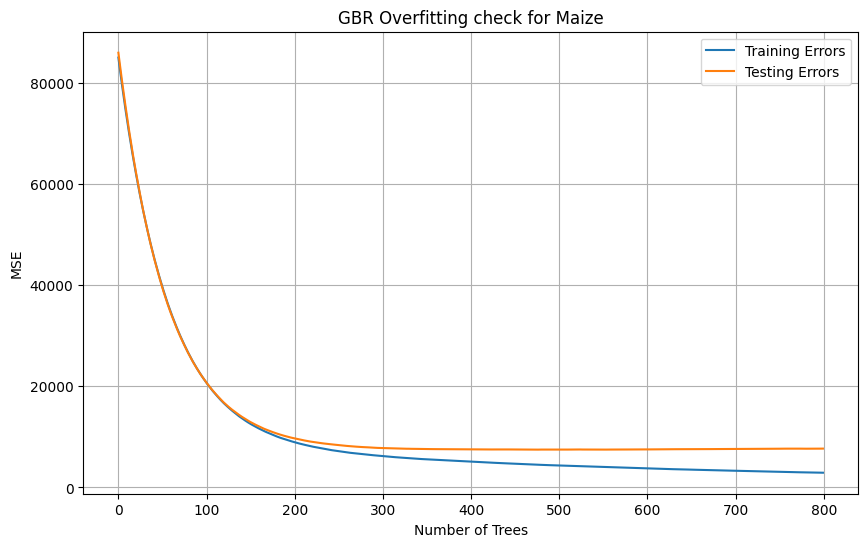

In [114]:
plt.figure(figsize=(10,6))
plt.plot(
    train_errors,
    label="Training Errors"
)
plt.plot(
    test_errors,
    label="Testing Errors"
)
plt.xlabel("Number of Trees")
plt.ylabel("MSE")
plt.title("GBR Overfitting check for Maize")
plt.legend()
plt.grid(True)
plt.show()

In [105]:
import joblib
joblib.dump(rfr,"model_rice.pkl")

['model_rice.pkl']

In [106]:
import joblib

feature_columns = x.columns.tolist()

joblib.dump(
    feature_columns,
    "feature_columns_rice.pkl"
)

['feature_columns_rice.pkl']

Text(0.5, 1.0, 'Rice Crop (Actual vs Predicted)')

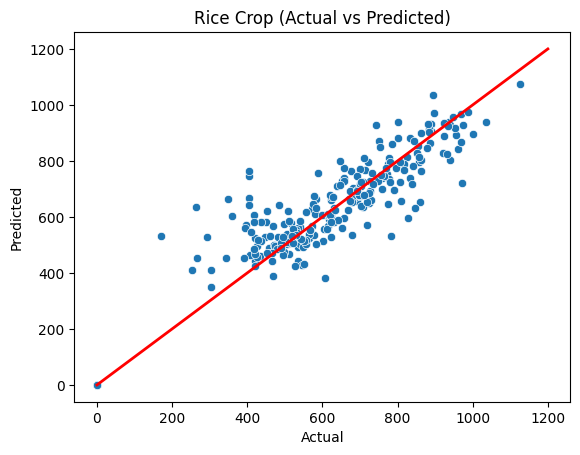

In [107]:
sns.scatterplot(x=y_test,y=rfr_pred)
plt.plot([0,1200],
         [0,1200],
         color='r',
         linestyle='-',
         linewidth=2)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Rice Crop (Actual vs Predicted)")

In [108]:
import shap

In [109]:
explainer=shap.Explainer(rfr)
shap_values=explainer(x.drop("year",axis=1))

In [110]:
np.shape(shap_values.values)

(1524, 53)

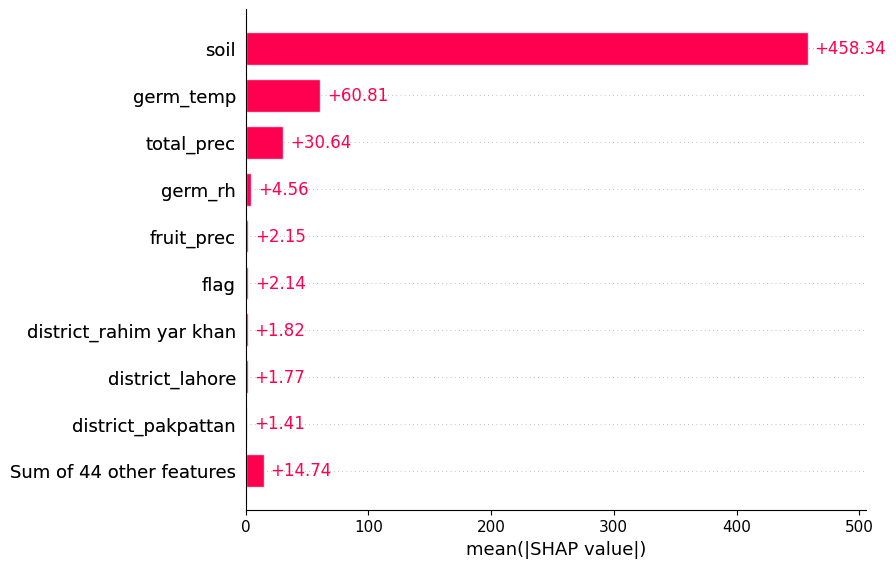

In [111]:
shap.plots.bar(shap_values)